In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
from astropy import units as u
from astropy.constants import G, c
from disktab import AGNDisk
from pagn import Sirko
import pagn.constants as ct
import matplotlib.pyplot as plt
from contextlib import redirect_stdout
import io

#### Current issues revealed below:
- Why divergence in temperature
- what is causing the disktab model to break with alpha=1.0

In [ ]:
def make_models(M_msun, alpha, Mdot_kgs, N_pagn=5000, N_disktab=2000):
    """Generate both disktab and pagn disk models with matched parameters."""
    # disktab
    disk = AGNDisk()
    disk.M = M_msun * u.Msun
    disk.alpha = alpha
    disk.Mdot = Mdot_kgs * u.kg / u.s
    disk.generate(rvals=np.logspace(1, 7, N_disktab))
    Rg = (G * disk.M / c**2).to(u.m).value
    
    # pagn (suppress verbose output)
    sk = Sirko.SirkoAGN(Mbh=M_msun * ct.MSun, alpha=alpha, Mdot=Mdot_kgs)
    with redirect_stdout(io.StringIO()):
        sk.solve_disk(N=N_pagn)
    
    return disk, sk, Rg


def plot_comparison(disk, sk, Rg, title):
    """6-panel comparison: T, rho, H, cs, Q, Sigma vs R/Rg."""
    df = disk.model
    pagn_RRg = sk.R / Rg
    # Compute Sigma for pagn: Sigma = 2*rho*h (uniform slab, same as S&G)
    pagn_Sigma = 2 * sk.rho * sk.h

    # Q=1 transition radius (dimensionless R/Rg)
    sr_rRg = None
    if disk.selfreg_threshold is not None:
        sr_rRg = (disk.selfreg_threshold / disk.gRad).decompose().value
    
    panels = [
        
        ('Tc', sk.T, 'Temperature [K]'),
        ('rho', sk.rho, r'Density [kg/m$^3$]'),
        ('H', sk.h, 'Scale Height [m]'),
        ('cs', sk.cs, 'Sound Speed [m/s]'),
        ('Q', sk.Q, 'Toomre Q'),
        ('Sigma', pagn_Sigma, r'Surface Density [kg/m$^2$]'),
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title, fontsize=13)
    
    for ax, (dcol, pagn_y, ylabel) in zip(axes.flat, panels):
        ax.loglog(df['R/Rg'], df[dcol], '.', ms=1.5, label='disktab', alpha=0.8, zorder=2)
        ax.loglog(pagn_RRg, pagn_y, '.', ms=4, label='pagn', alpha=0.6, zorder=1)
        ax.set_xlabel('R / Rg')
        ax.set_ylabel(ylabel)
        if dcol == 'Q':
            ax.axhline(1, color='gray', ls='--', lw=0.8)
        if sr_rRg is not None:
            ax.axvline(sr_rRg, color='red', ls=':', lw=1.2,
                       label='Q=1 transition' if dcol == 'Tc' else None)
    
    axes[0, 0].legend(markerscale=5)
    fig.tight_layout()
    return fig

## Generate models

In [3]:
M = 1e8  # solar masses

cases = {
    'A': {'alpha': 0.1, 'Mdot': 7.22e22, 'label': r'$\alpha=0.1$, $\dot{M}=7.22\times10^{22}$ kg/s'},
    'B': {'alpha': 0.1, 'Mdot': 1.4e23,  'label': r'$\alpha=0.1$, $\dot{M}=1.4\times10^{23}$ kg/s'},
    'C': {'alpha': 1.0, 'Mdot': 1.4e23,  'label': r'$\alpha=1.0$, $\dot{M}=1.4\times10^{23}$ kg/s'},
}

results = {}
for key, params in cases.items():
    print(f"Case {key}: {params['label']}")
    disk, sk, Rg = make_models(M, params['alpha'], params['Mdot'])
    results[key] = (disk, sk, Rg, params['label'])

Case A: $\alpha=0.1$, $\dot{M}=7.22\times10^{22}$ kg/s
### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 1.145835e+00 MSun/yr
le = 0.44126774840650695
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e+01 pc
alpha = 0.1
b = 0
eps = 0.1
X = 0.7
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
Case B: $\alpha=0.1$, $\dot{M}=1.4\times10^{23}$ kg/s
### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 2.221841e+00 MSun/yr
le = 0.8556438334752214
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e+01 pc
alpha = 0.1
b = 0
eps = 0.1
X = 0.7
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
Case C: $\alpha=1.0$, $\dot{M}=1.4\times10^{23}$ kg/s
### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 2.221841e+00 MSun/yr
le = 0.8556438334752214
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e+01 pc
alpha = 1.0
b = 0
eps = 0.1
X = 0.7


## Comparisons

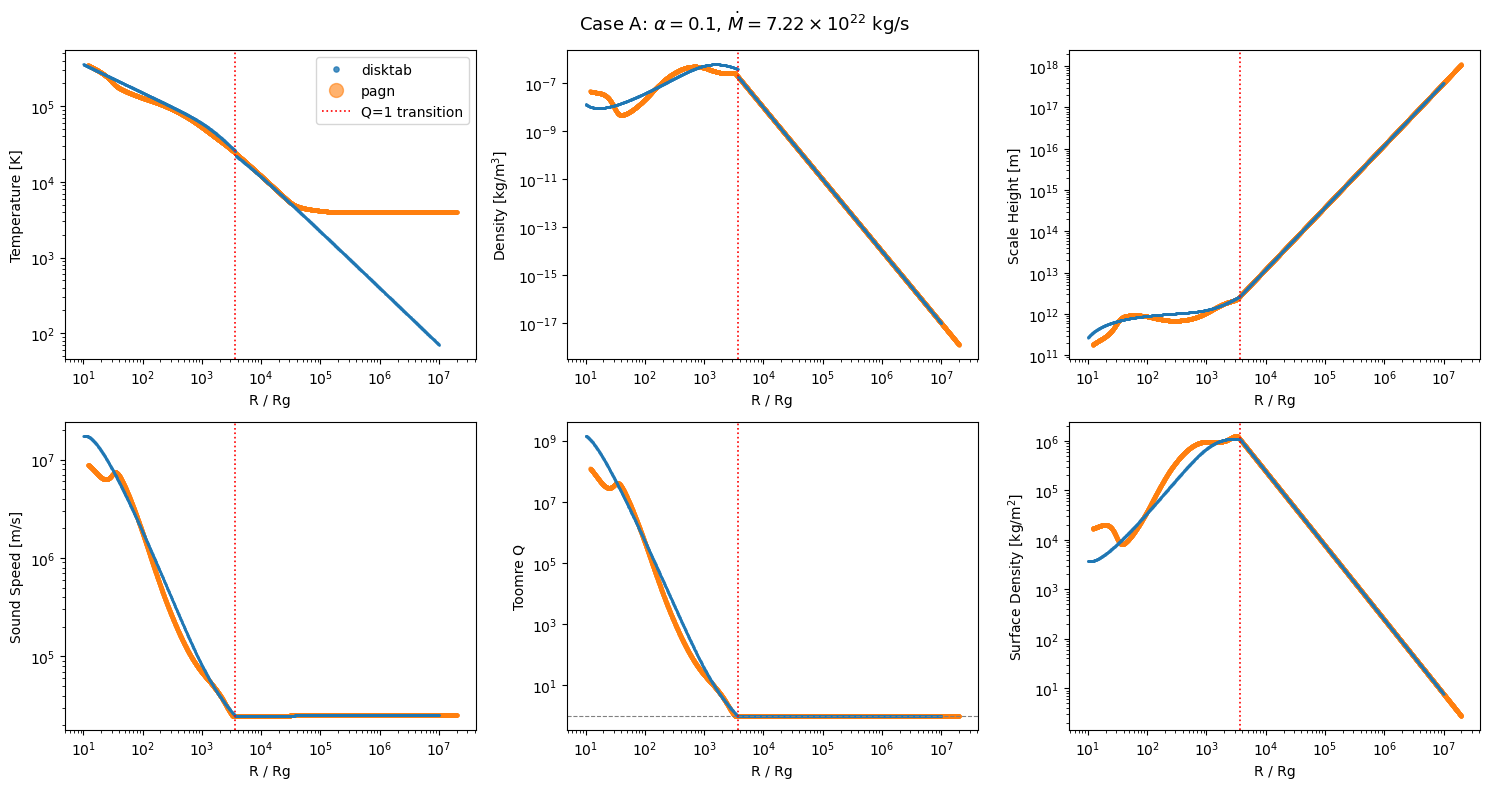

In [4]:
disk, sk, Rg, label = results['A']
fig = plot_comparison(disk, sk, Rg, f'Case A: {label}')

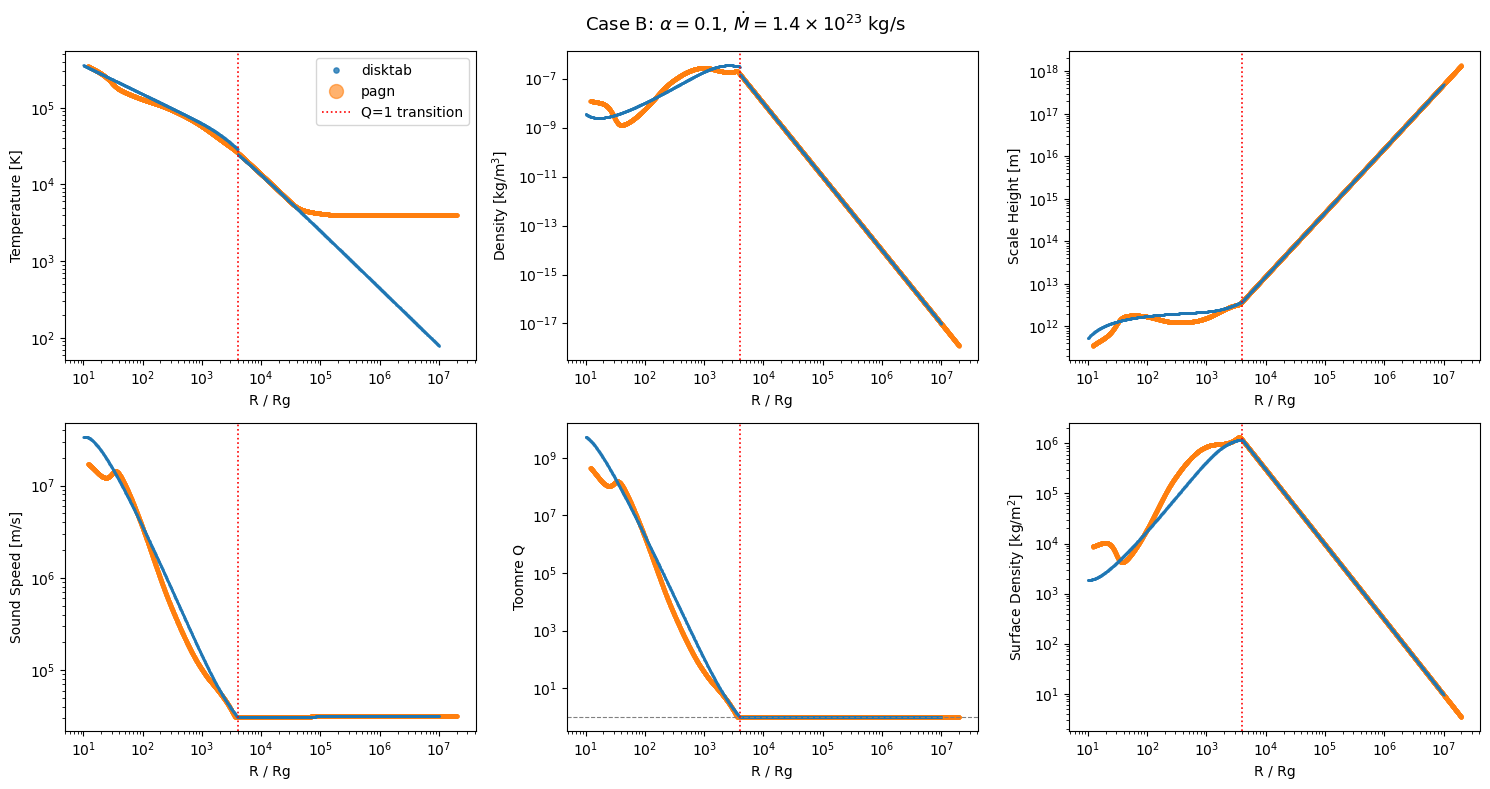

In [5]:
disk, sk, Rg, label = results['B']
fig = plot_comparison(disk, sk, Rg, f'Case B: {label}')

## Case B / Case A Ratio Plot
The cases look identical on log-log because Mdot enters weakly (as Mdot^1/3) in the Self-Reg zone.
This ratio plot reveals the actual numerical differences.

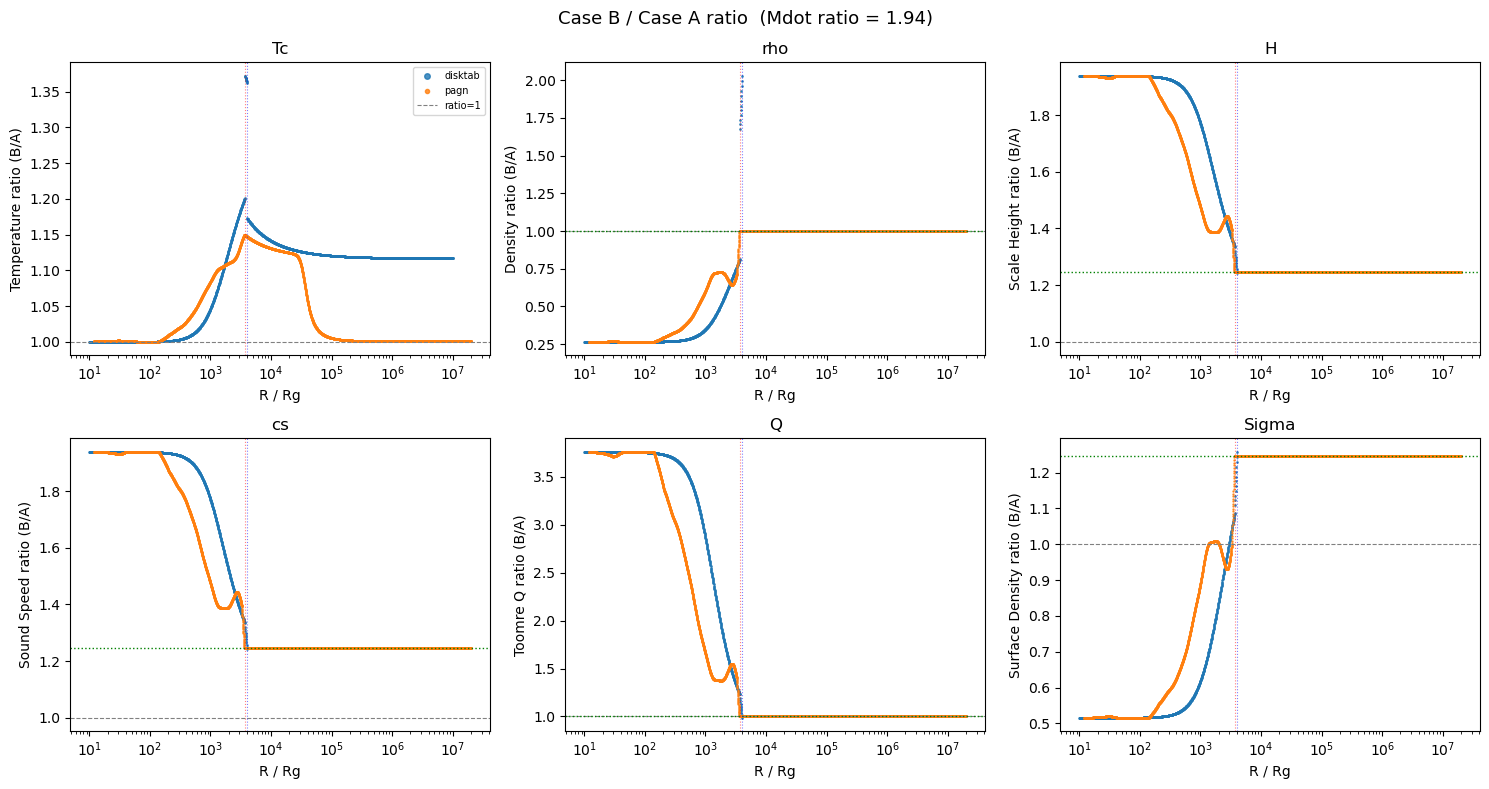

In [6]:
disk_A, sk_A, Rg_A, label_A = results['A']
disk_B, sk_B, Rg_B, label_B = results['B']

df_A = disk_A.model
df_B = disk_B.model

# Expected Mdot ratio and power-law scalings
Mdot_ratio = cases['B']['Mdot'] / cases['A']['Mdot']

# Quantities and their expected Self-Reg scaling exponent (Mdot^n)
panels = [
    ('Tc',    'Temperature',       None),   # complex: depends on gas vs rad pressure
    ('rho',   'Density',           0),      # rho = Omega^2/(2piG), independent of Mdot
    ('H',     'Scale Height',      1/3),    # H = cs/Omega, cs ~ Mdot^(1/3)
    ('cs',    'Sound Speed',       1/3),
    ('Q',     'Toomre Q',          0),      # Q=1 by definition in Self-Reg
    ('Sigma', 'Surface Density',   1/3),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Case B / Case A ratio  (Mdot ratio = {Mdot_ratio:.2f})', fontsize=13)

for ax, (col, name, sr_exp) in zip(axes.flat, panels):
    # --- disktab ratio ---
    # Both cases use the same R/Rg grid, so direct division works
    ratio_dt = df_B[col].values / df_A[col].values
    ax.semilogx(df_A['R/Rg'], ratio_dt, '.', ms=2, label='disktab', alpha=0.8)

    # --- pagn ratio ---
    # pagn grids differ slightly; interpolate B onto A's grid
    pagn_RRg_A = sk_A.R / Rg_A
    pagn_RRg_B = sk_B.R / Rg_B

    if col == 'Sigma':
        pagn_A = 2 * sk_A.rho * sk_A.h
        pagn_B = 2 * sk_B.rho * sk_B.h
    else:
        pagn_A = getattr(sk_A, {'Tc': 'T', 'H': 'h'}.get(col, col))
        pagn_B = getattr(sk_B, {'Tc': 'T', 'H': 'h'}.get(col, col))

    # Interpolate pagn_B onto pagn_A's radial grid
    pagn_B_interp = np.interp(pagn_RRg_A, pagn_RRg_B, pagn_B)
    mask = (pagn_A > 0) & (pagn_B_interp > 0)
    ratio_pagn = pagn_B_interp[mask] / pagn_A[mask]
    ax.semilogx(pagn_RRg_A[mask], ratio_pagn, '.', ms=1.5, label='pagn', alpha=0.8)

    # Reference lines
    ax.axhline(1.0, color='gray', ls='--', lw=0.8, label='ratio=1')
    if sr_exp is not None:
        expected = Mdot_ratio ** sr_exp
        ax.axhline(expected, color='green', ls=':', lw=1,
                   label=f'Mdot^({sr_exp:.1g}) = {expected:.3f}')

    # Q=1 transition
    for res, style in [(disk_A, 'red'), (disk_B, 'blue')]:
        if res.selfreg_threshold is not None:
            sr = (res.selfreg_threshold / res.gRad).decompose().value
            ax.axvline(sr, color=style, ls=':', lw=0.8, alpha=0.5)

    ax.set_xlabel('R / Rg')
    ax.set_ylabel(f'{name} ratio (B/A)')
    ax.set_title(col)

axes[0, 0].legend(fontsize=7, markerscale=4)
fig.tight_layout()
plt.show()

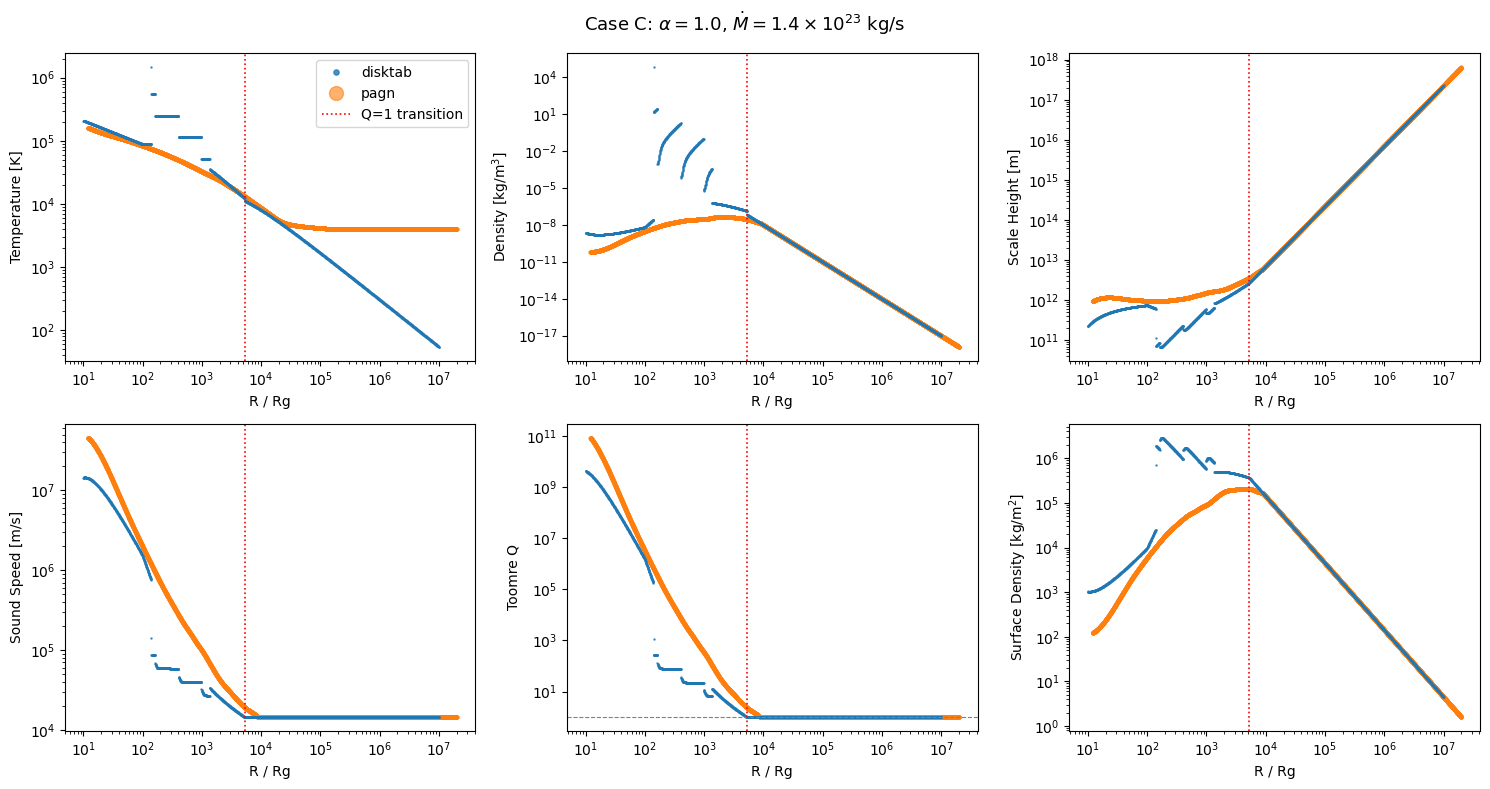

In [7]:
disk, sk, Rg, label = results['C']
fig = plot_comparison(disk, sk, Rg, f'Case C: {label}')